# Stock Direction v11.2: Neural Trading Model for Large Up Moves

This notebook takes the lessons from `v11_1` and simplifies the trading problem:

- target the days with **large positive next-day returns** instead of generic up/down,
- use a **long-only** MLP with `no-trade` as the default,
- keep the strict time validation:
  - rolling `12M train / 3M validation`,
  - untouched final `6M` holdout.

The notebook also reports **peak capture** metrics, so it is easier to see whether the model is still missing large upside moves.


In [1]:
from itertools import product
from pathlib import Path
import ast
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)

RANDOM_STATE = 42
FINAL_HOLDOUT_MONTHS = 6
TRAIN_MONTHS = 12
VAL_MONTHS = 3
STEP_MONTHS = 1
ONE_WAY_COST = 0.0005
MIN_POSITIVE_SAMPLES = 25
MIN_ACTIVE_PCT = 0.08
STABILITY_TOP_N = 15

UP_MOVE_BANDS = [0.015, 0.02, 0.025]
TOP_K_VALUES = [8, 12]
HIDDEN_CHOICES = [(8,), (16,), (16, 8)]
ALPHA_VALUES = [0.001, 0.01]
LR_VALUES = [0.001]
LONG_PROB_THRESHOLDS = [0.45, 0.50, 0.55, 0.60]


In [2]:
def rank_features_mi(X_train, y_train):
    if X_train.empty:
        return pd.DataFrame(columns=["feature", "mi", "rank"])
    imp = SimpleImputer(strategy="median")
    X_i = imp.fit_transform(X_train)
    mi = mutual_info_classif(X_i, y_train.astype(int), random_state=RANDOM_STATE)
    ranked = pd.DataFrame({"feature": X_train.columns, "mi": mi}).sort_values(
        ["mi", "feature"], ascending=[False, True]
    ).reset_index(drop=True)
    ranked["rank"] = np.arange(1, len(ranked) + 1)
    return ranked


def fit_mlp(train_X, train_y, selected_cols, hidden_layers, alpha_value, learning_rate):
    model = Pipeline(
        steps=[
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler()),
            (
                "clf",
                MLPClassifier(
                    hidden_layer_sizes=tuple(hidden_layers),
                    activation="relu",
                    solver="adam",
                    alpha=float(alpha_value),
                    learning_rate_init=float(learning_rate),
                    batch_size=32,
                    max_iter=500,
                    early_stopping=True,
                    n_iter_no_change=20,
                    validation_fraction=0.15,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )
    model.fit(train_X[selected_cols], train_y)
    return model


def build_fixed_windows(df, train_months, test_months, step_months):
    windows = []
    min_date = df["date"].min().normalize()
    max_date = df["date"].max().normalize()
    test_start = (min_date + pd.DateOffset(months=train_months)).normalize()
    window_id = 1

    while test_start <= max_date:
        train_start = (test_start - pd.DateOffset(months=train_months)).normalize()
        test_end = (test_start + pd.DateOffset(months=test_months)).normalize()

        tr = df[(df["date"] >= train_start) & (df["date"] < test_start)].copy()
        te = df[(df["date"] >= test_start) & (df["date"] < test_end)].copy()
        if te.empty:
            break
        if not tr.empty:
            windows.append(
                {
                    "window_id": window_id,
                    "train_start": train_start,
                    "train_end": test_start - pd.Timedelta(days=1),
                    "test_start": test_start,
                    "test_end": min(test_end - pd.Timedelta(days=1), te["date"].max()),
                    "train_df": tr,
                    "test_df": te,
                }
            )
            window_id += 1
        test_start = (test_start + pd.DateOffset(months=step_months)).normalize()

    return windows


def compute_stability_table(windows, feature_cols, up_move_band, top_n):
    rankings = []
    valid_windows = 0

    for window in windows:
        tr = window["train_df"]
        y = (tr["future_return_1d"] > up_move_band).astype(int).to_numpy()
        if y.sum() < MIN_POSITIVE_SAMPLES or len(np.unique(y)) < 2:
            continue
        ranked = rank_features_mi(tr[feature_cols], y)
        if ranked.empty:
            continue
        ranked["window_id"] = window["window_id"]
        rankings.append(ranked)
        valid_windows += 1

    if not rankings or valid_windows == 0:
        return pd.DataFrame(
            columns=[
                "up_move_band",
                "feature",
                "freq_top_n",
                "coverage",
                "mean_rank",
                "mean_mi",
                "top_n_hits",
                "n_windows",
            ]
        )

    ranking_df = pd.concat(rankings, ignore_index=True)
    summary = ranking_df.groupby("feature").agg(
        mean_rank=("rank", "mean"),
        mean_mi=("mi", "mean"),
        appearances=("window_id", "nunique"),
        top_n_hits=("rank", lambda s: int((s <= top_n).sum())),
    ).reset_index()
    summary["up_move_band"] = up_move_band
    summary["n_windows"] = valid_windows
    summary["coverage"] = summary["appearances"] / valid_windows
    summary["freq_top_n"] = summary["top_n_hits"] / valid_windows
    summary = summary.sort_values(
        ["freq_top_n", "mean_rank", "mean_mi", "feature"],
        ascending=[False, True, False, True],
    ).reset_index(drop=True)
    return summary[["up_move_band", "feature", "freq_top_n", "coverage", "mean_rank", "mean_mi", "top_n_hits", "n_windows"]]


def top_features_from_stability(stability_df, top_k):
    if stability_df.empty:
        return []
    ordered = stability_df["feature"].tolist()
    return ordered[: min(int(top_k), len(ordered))]


def fit_peak_model(train_df, stability_df, top_k, hidden_layers, alpha_value, learning_rate, up_move_band):
    y_peak = (train_df["future_return_1d"] > up_move_band).astype(int).to_numpy()
    if y_peak.sum() < MIN_POSITIVE_SAMPLES or len(np.unique(y_peak)) < 2:
        return None

    selected_cols = top_features_from_stability(stability_df, top_k)
    if not selected_cols:
        return None

    model = fit_mlp(
        train_df,
        y_peak,
        selected_cols,
        hidden_layers=hidden_layers,
        alpha_value=alpha_value,
        learning_rate=learning_rate,
    )
    return {
        "model": model,
        "selected_cols": selected_cols,
        "hidden_layers": tuple(hidden_layers),
        "alpha_value": float(alpha_value),
        "learning_rate": float(learning_rate),
        "up_move_band": float(up_move_band),
    }


def predict_long_only(bundle, frame, long_prob_thr):
    p_peak = bundle["model"].predict_proba(frame[bundle["selected_cols"]])[:, 1]
    signal = (p_peak >= long_prob_thr).astype(int)
    return signal, p_peak


def backtest_long_only(future_returns, signal, one_way_cost):
    r = np.asarray(future_returns, dtype=float)
    s = np.asarray(signal, dtype=int)
    trade_mask = s == 1
    strat_ret = np.zeros(len(s), dtype=float)
    strat_ret[trade_mask] = r[trade_mask] - 2.0 * one_way_cost
    return strat_ret, trade_mask, s


def perf_stats_long(strat_ret, trade_mask, signal, future_returns, up_move_band):
    strat_ret = np.asarray(strat_ret, dtype=float)
    trade_mask = np.asarray(trade_mask, dtype=bool)
    signal = np.asarray(signal, dtype=int)
    future_returns = np.asarray(future_returns, dtype=float)

    equity = np.cumprod(1 + strat_ret)
    running_max = np.maximum.accumulate(equity)
    drawdown = equity / running_max - 1

    sharpe = 0.0
    if len(strat_ret) > 1 and np.std(strat_ret, ddof=1) > 0:
        sharpe = float(np.sqrt(252) * np.mean(strat_ret) / np.std(strat_ret, ddof=1))

    n_active = int(trade_mask.sum())
    hit_rate = float(np.mean(strat_ret[trade_mask] > 0)) if n_active else np.nan

    big_up_mask = future_returns > up_move_band
    big_up_days = int(big_up_mask.sum())
    big_up_captured = int(np.sum(big_up_mask & trade_mask))
    big_up_capture_rate = float(big_up_captured / big_up_days) if big_up_days else np.nan
    peak_precision = float(np.mean(big_up_mask[trade_mask])) if n_active else np.nan

    long_active = strat_ret[trade_mask]
    return {
        "cum_return": float(equity[-1] - 1),
        "sharpe": sharpe,
        "max_drawdown": float(drawdown.min()),
        "avg_daily_return": float(np.mean(strat_ret)),
        "active_days": n_active,
        "active_pct": float(np.mean(trade_mask)),
        "entries_exits": float(n_active * 2),
        "hit_rate_active": hit_rate,
        "long_days": n_active,
        "long_avg_ret": float(np.mean(long_active)) if long_active.size else np.nan,
        "long_hit_rate": float(np.mean(long_active > 0)) if long_active.size else np.nan,
        "big_up_days": big_up_days,
        "big_up_captured": big_up_captured,
        "big_up_capture_rate": big_up_capture_rate,
        "peak_precision_active": peak_precision,
    }


cwd = Path.cwd().resolve()
project_root = next(
    (
        base
        for base in [cwd, *cwd.parents]
        if (base / "data" / "equity_data" / "model_data").exists()
    ),
    None,
)
if project_root is None:
    raise FileNotFoundError(f"Could not locate project root from cwd={cwd}")

candidate_paths = [
    project_root / "data" / "equity_data" / "model_data" / "stock_direction_dataset_v11_1_lagged.csv",
]
source_path = next((p for p in candidate_paths if p.exists()), None)
if source_path is None:
    raise FileNotFoundError("No v11.1 lagged dataset found for v11.2.")

df = pd.read_csv(source_path)
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)
for c in df.columns:
    if c != "date":
        df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.replace([np.inf, -np.inf], np.nan)
df["future_return_1d"] = pd.to_numeric(df["future_return_1d"], errors="coerce")
rows_before = len(df)
df = df.dropna(subset=["future_return_1d"]).reset_index(drop=True)
df["abs_future_return_1d"] = df["future_return_1d"].abs()
dropped_rows = rows_before - len(df)

feature_cols = [c for c in df.columns if c not in ["date", "future_return_1d", "y_dir", "abs_future_return_1d"]]

holdout_start = df["date"].max() - pd.DateOffset(months=FINAL_HOLDOUT_MONTHS)
train_pool = df[df["date"] < holdout_start].copy()
final_test_df = df[df["date"] >= holdout_start].copy()
rolling_windows = build_fixed_windows(train_pool, TRAIN_MONTHS, VAL_MONTHS, STEP_MONTHS)
final_train_df = train_pool.copy()

stability_tables = {}
stability_rows = []
for band in UP_MOVE_BANDS:
    band_df = compute_stability_table(rolling_windows, feature_cols, band, STABILITY_TOP_N)
    stability_tables[band] = band_df
    stability_rows.append(band_df)
feature_stability_df = pd.concat(stability_rows, ignore_index=True) if stability_rows else pd.DataFrame()

configs_per_model = (
    len(UP_MOVE_BANDS)
    * len(TOP_K_VALUES)
    * len(HIDDEN_CHOICES)
    * len(ALPHA_VALUES)
    * len(LR_VALUES)
    * len(LONG_PROB_THRESHOLDS)
)

output_dir = project_root / "data" / "equity_data" / "model_data"
output_dir.mkdir(parents=True, exist_ok=True)

base_out_path = output_dir / "stock_direction_dataset_v11_2_base.csv"
stability_out_path = output_dir / "stock_direction_v11_2_feature_stability.csv"
df.to_csv(base_out_path, index=False)
feature_stability_df.to_csv(stability_out_path, index=False)

print(f"Current working directory: {cwd}")
print(f"Project root: {project_root}")
print(f"Using source dataset: {source_path}")
print(f"Rows after cleaning: {len(df)}")
print(f"Rows dropped due to missing target: {dropped_rows}")
print(f"Feature columns: {len(feature_cols)}")
print(f"Rolling windows: {len(rolling_windows)}")
print(f"Final train rows: {len(final_train_df)}")
print(f"Final holdout rows: {len(final_test_df)}")
print(f"Total v11.2 candidates: {configs_per_model}")
print(f"Saved base dataset to {base_out_path}")
print(f"Saved feature stability to {stability_out_path}")
for band in UP_MOVE_BANDS:
    print(f'Band {band}: stability rows={len(stability_tables[band])}')
display(feature_stability_df.head(20))


Current working directory: C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code\notebooks
Project root: C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code
Using source dataset: C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code\data\equity_data\model_data\stock_direction_dataset_v11_1_lagged.csv
Rows after cleaning: 750
Rows dropped due to missing target: 0
Feature columns: 114
Rolling windows: 18
Final train rows: 623
Final holdout rows: 127
Total v11.2 candidates: 144
Saved base dataset to C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code\data\equity_data\model_data\stock_direction_dataset_v11_2_base.csv
Saved feature stability to C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code\data\equity_data\model_data\stock_direction_v11_2_feature_stability.csv
Band 0.015: stability rows=114
Band 0.02: stability rows=114
Band 0.025: stability rows=114


,up_move_band,feature,freq_top_n,coverage,mean_rank,mean_mi,top_n_hits,n_windows
0,0.015,volume_vs_sma_20d,0.611111,1.0,32.222222,0.035578,11,18
1,0.015,realized_vol_5d_delta5,0.555556,1.0,11.666667,0.044393,10,18
2,0.015,subm_posts_z20_mean3,0.500000,1.0,26.111111,0.035177,9,18
3,0.015,price_vs_sma_10d_mean3,0.500000,1.0,38.222222,0.024018,9,18
4,0.015,trends_change_7d_lag7,0.500000,1.0,49.000000,0.038074,9,18
5,0.015,subm_posts_z20,0.444444,1.0,23.166667,0.036645,8,18
6,0.015,ret_1d_lag5,0.444444,1.0,31.166667,0.027954,8,18
7,0.015,volume_z20_delta5,0.388889,1.0,28.166667,0.030535,7,18
8,0.015,ret_5d,0.388889,1.0,33.111111,0.023774,7,18
9,0.015,price_vs_sma_5d_lag1,0.388889,1.0,38.555556,0.029196,7,18


Starting v11.2 rolling search with 144 candidates
[Config 1/144] band=0.015, top_k=8, hidden=(8,), alpha=0.001, lr=0.001, long_thr=0.45
  window 1/18
  window 5/18
  window 10/18
  window 15/18
  window 18/18
  done: score=0.3019, mean_cum=0.0136, capture=0.3900, peak_precision=0.3256, active=0.4055
[Config 2/144] band=0.015, top_k=8, hidden=(8,), alpha=0.001, lr=0.001, long_thr=0.5
  window 1/18
  window 5/18
  window 10/18
  window 15/18
  window 18/18
  done: score=0.3064, mean_cum=0.0242, capture=0.3442, peak_precision=0.3227, active=0.3462
[Config 3/144] band=0.015, top_k=8, hidden=(8,), alpha=0.001, lr=0.001, long_thr=0.55
  window 1/18
  window 5/18
  window 10/18
  window 15/18
  window 18/18
  done: score=0.2583, mean_cum=0.0016, capture=0.2554, peak_precision=0.3058, active=0.2726
[Config 4/144] band=0.015, top_k=8, hidden=(8,), alpha=0.001, lr=0.001, long_thr=0.6
  window 1/18
  window 5/18
  window 10/18
  window 15/18
  window 18/18
  done: score=0.1578, mean_cum=-0.0074, 

,up_move_band,top_k,hidden_layers,alpha_value,learning_rate,long_prob_thr,rolling_score,rolling_mean_cum_return,rolling_median_cum_return,rolling_mean_sharpe,rolling_mean_drawdown,rolling_mean_active_pct,rolling_mean_hit_rate,rolling_mean_big_up_capture,rolling_mean_peak_precision,rolling_profitable_window_pct,n_windows
0,0.020,12,"(16,)",0.001,0.001,0.55,0.502338,0.051501,0.050101,1.386468,-0.025192,0.063989,0.675641,0.128655,0.496154,0.611111,18
1,0.020,12,"(16,)",0.010,0.001,0.55,0.502338,0.051501,0.050101,1.386468,-0.025192,0.063989,0.675641,0.128655,0.496154,0.611111,18
2,0.025,12,"(8,)",0.001,0.001,0.50,0.440039,0.034041,0.027337,0.940488,-0.070495,0.131108,0.573728,0.166744,0.376534,0.722222,18
3,0.025,12,"(8,)",0.010,0.001,0.50,0.440039,0.034041,0.027337,0.940488,-0.070495,0.131108,0.573728,0.166744,0.376534,0.722222,18
4,0.020,8,"(8,)",0.001,0.001,0.60,0.410194,0.036372,0.034644,0.847835,-0.047178,0.093973,0.584540,0.136222,0.413127,0.666667,18
5,0.020,8,"(8,)",0.010,0.001,0.60,0.410194,0.036372,0.034644,0.847835,-0.047178,0.093973,0.584540,0.136222,0.413127,0.666667,18
6,0.020,12,"(16,)",0.010,0.001,0.60,0.392826,0.031037,0.013695,1.248054,-0.016770,0.042680,0.770661,0.097489,0.646694,0.500000,18
7,0.020,12,"(16,)",0.001,0.001,0.60,0.392826,0.031037,0.013695,1.248054,-0.016770,0.042680,0.770661,0.097489,0.646694,0.500000,18
8,0.020,8,"(8,)",0.010,0.001,0.55,0.372785,0.030356,0.024676,0.670336,-0.067148,0.146395,0.511872,0.187808,0.344638,0.722222,18
9,0.020,8,"(8,)",0.001,0.001,0.55,0.372785,0.030356,0.024676,0.670336,-0.067148,0.146395,0.511872,0.187808,0.344638,0.722222,18


Best v11.2 config: {'up_move_band': 0.02, 'top_k': 12, 'hidden_layers': '(16,)', 'alpha_value': 0.001, 'learning_rate': 0.001, 'long_prob_thr': 0.55, 'rolling_score': 0.5023382020668986, 'rolling_mean_cum_return': 0.05150128633708026, 'rolling_median_cum_return': 0.05010091038061226, 'rolling_mean_sharpe': 1.3864684901017885, 'rolling_mean_drawdown': -0.025192276773569, 'rolling_mean_active_pct': 0.06398930555426702, 'rolling_mean_hit_rate': 0.6756410256410257, 'rolling_mean_big_up_capture': 0.12865520678343176, 'rolling_mean_peak_precision': 0.49615384615384617, 'rolling_profitable_window_pct': 0.6111111111111112, 'n_windows': 18}
Re-running best v11.2 config across rolling windows...
  best-config window 1/18
  best-config window 5/18
  best-config window 10/18
  best-config window 15/18
  best-config window 18/18


,window_id,train_start,train_end,test_start,test_end,features_used,cum_return,sharpe,max_drawdown,avg_daily_return,...,active_pct,entries_exits,hit_rate_active,long_days,long_avg_ret,long_hit_rate,big_up_days,big_up_captured,big_up_capture_rate,peak_precision_active
0,1,2023-01-03,2024-01-02,2024-01-03,2024-04-02,12,0.0812,2.1373,-0.0180,0.0013,...,0.0806,10.0,0.6000,5,0.0162,0.6000,9,2,0.2222,0.4000
1,2,2023-02-03,2024-02-02,2024-02-03,2024-05-02,12,0.1232,1.5645,-0.0728,0.0021,...,0.1613,20.0,0.6000,10,0.0129,0.6000,13,4,0.3077,0.4000
2,3,2023-03-03,2024-03-02,2024-03-03,2024-05-31,12,-0.0299,-2.0000,-0.0299,-0.0005,...,0.0159,2.0,0.0000,1,-0.0299,0.0000,12,0,0.0000,0.0000
3,4,2023-04-03,2024-04-02,2024-04-03,2024-07-02,12,0.0552,1.2789,-0.0299,0.0009,...,0.0635,8.0,0.5000,4,0.0144,0.5000,17,2,0.1176,0.5000
4,5,2023-05-03,2024-05-02,2024-05-03,2024-08-02,12,0.1311,1.6566,-0.0854,0.0022,...,0.1905,24.0,0.7500,12,0.0114,0.7500,18,5,0.2778,0.4167
5,6,2023-06-03,2024-06-02,2024-06-03,2024-08-30,12,0.1173,2.7950,-0.0254,0.0018,...,0.0952,12.0,0.8333,6,0.0190,0.8333,20,3,0.1500,0.5000
6,7,2023-07-03,2024-07-02,2024-07-03,2024-10-02,12,0.0821,3.6020,0.0000,0.0012,...,0.0781,10.0,1.0000,5,0.0160,1.0000,19,2,0.1053,0.4000
7,8,2023-08-03,2024-08-02,2024-08-03,2024-11-01,12,0.0406,2.4193,0.0000,0.0006,...,0.0469,6.0,1.0000,3,0.0134,1.0000,16,1,0.0625,0.3333
8,9,2023-09-03,2024-09-02,2024-09-03,2024-12-02,12,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0,NaN,0,NaN,NaN,21,0,0.0000,NaN
9,10,2023-10-03,2024-10-02,2024-10-03,2025-01-02,12,-0.0044,-0.1319,-0.0356,-0.0001,...,0.0317,4.0,0.5000,2,-0.0016,0.5000,24,1,0.0417,0.5000


Fitting best v11.2 config on final training split...
Scoring final train and holdout splits...


,model,split,cum_return,sharpe,max_drawdown,avg_daily_return,active_days,active_pct,entries_exits,hit_rate_active,long_days,long_avg_ret,long_hit_rate,big_up_days,big_up_captured,big_up_capture_rate,peak_precision_active
0,BuyHold,train,1.9386,1.0064,-0.5377,0.0025,623,1.0000,1246.0,0.5152,623,0.0025,0.5152,172,172,1.0000,0.2761
1,BuyHold,test,0.4306,1.7463,-0.1650,0.0033,127,1.0000,254.0,0.5433,127,0.0033,0.5433,35,35,1.0000,0.2756
2,PeakLong_MLP_v11_2,train,0.2627,0.5667,-0.2307,0.0005,53,0.0851,106.0,0.5849,53,0.0054,0.5849,172,22,0.1279,0.4151
3,PeakLong_MLP_v11_2,test,0.0497,0.9960,-0.0448,0.0004,7,0.0551,14.0,0.7143,7,0.0073,0.7143,35,3,0.0857,0.4286


,feature,selected_rank,up_move_band,hidden_layers,alpha_value,learning_rate,long_prob_thr,stability_freq_top_n,stability_coverage,stability_mean_rank,stability_mean_mi
0,subm_posts_z20,1,0.02,"(16,)",0.001,0.001,0.55,0.611111,1.0,18.000000,0.035504
1,volume_z20_delta5,2,0.02,"(16,)",0.001,0.001,0.55,0.611111,1.0,21.666667,0.032502
2,ret_1d_delta1,3,0.02,"(16,)",0.001,0.001,0.55,0.611111,1.0,26.111111,0.027874
3,realized_vol_5d_delta5,4,0.02,"(16,)",0.001,0.001,0.55,0.500000,1.0,17.000000,0.028926
4,volume_vs_sma_20d_lag5,5,0.02,"(16,)",0.001,0.001,0.55,0.444444,1.0,27.666667,0.026330
5,ret_5d,6,0.02,"(16,)",0.001,0.001,0.55,0.444444,1.0,34.000000,0.021634
6,subm_posts_z20_mean3,7,0.02,"(16,)",0.001,0.001,0.55,0.388889,1.0,29.166667,0.027689
7,ret_1d_lag2,8,0.02,"(16,)",0.001,0.001,0.55,0.388889,1.0,35.555556,0.016196
8,volume_vs_sma_20d_mean3,9,0.02,"(16,)",0.001,0.001,0.55,0.388889,1.0,44.555556,0.019196
9,subm_posts_z20_delta1,10,0.02,"(16,)",0.001,0.001,0.55,0.388889,1.0,46.555556,0.014229


Preparing peak-capture report and plots...
Classification report for large-up target on full holdout:
              precision    recall  f1-score   support

           0     0.7333    0.9565    0.8302        92
           1     0.4286    0.0857    0.1429        35

    accuracy                         0.7165       127
   macro avg     0.5810    0.5211    0.4865       127
weighted avg     0.6493    0.7165    0.6408       127



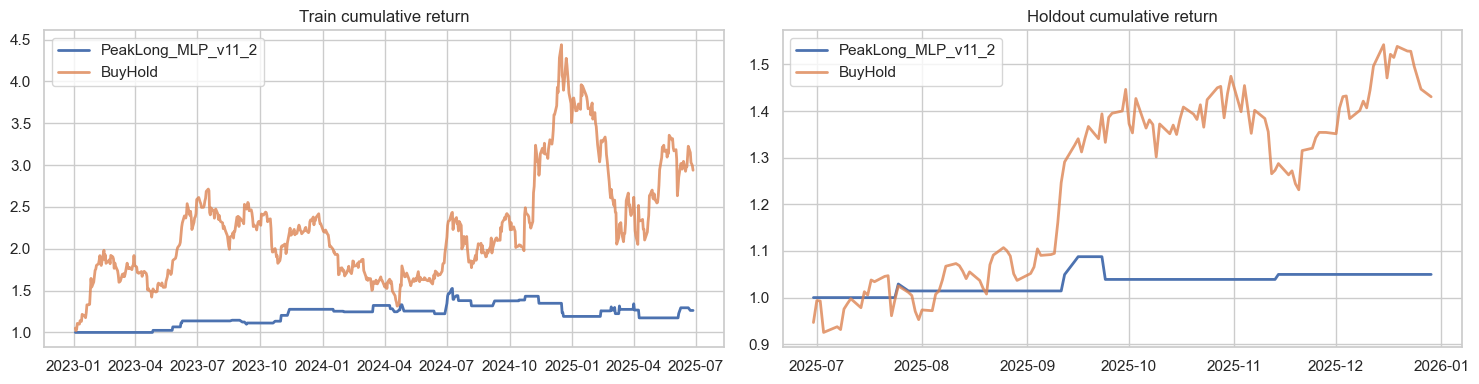

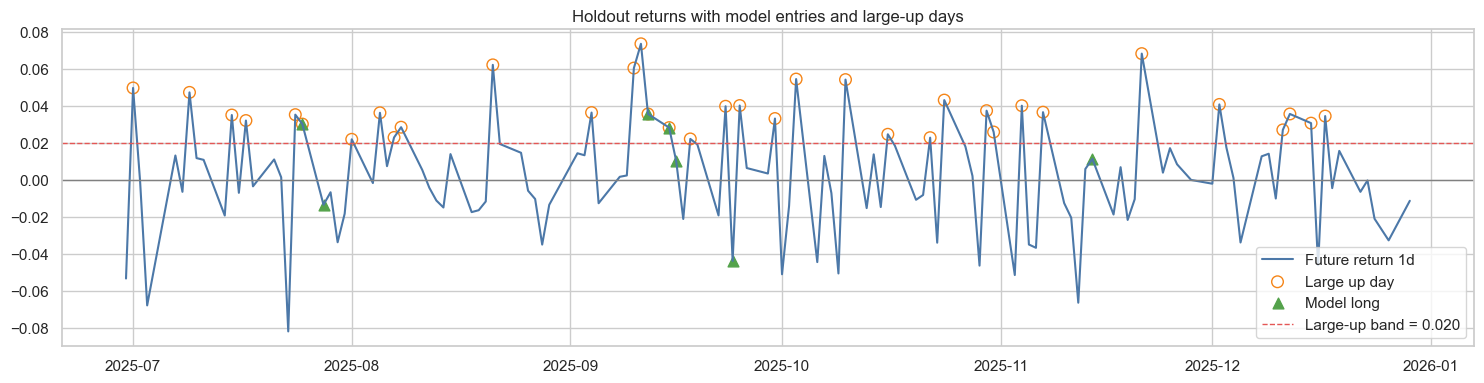

Saved search results to C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code\data\equity_data\model_data\stock_direction_v11_2_search_results.csv
Saved rolling results to C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code\data\equity_data\model_data\stock_direction_v11_2_rolling_window_results.csv
Saved metrics to C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code\data\equity_data\model_data\stock_direction_v11_2_metrics.csv
Saved test predictions to C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code\data\equity_data\model_data\stock_direction_v11_2_test_predictions.csv
Saved selected features to C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code\data\equity_data\model_data\stock_direction_v11_2_selected_features.csv


In [3]:
search_rows = []
config_counter = 0

print(f"Starting v11.2 rolling search with {configs_per_model} candidates")

for (
    up_move_band,
    top_k,
    hidden_layers,
    alpha_value,
    learning_rate,
    long_prob_thr,
) in product(
    UP_MOVE_BANDS,
    TOP_K_VALUES,
    HIDDEN_CHOICES,
    ALPHA_VALUES,
    LR_VALUES,
    LONG_PROB_THRESHOLDS,
):
    config_counter += 1
    print(
        f"[Config {config_counter}/{configs_per_model}] "
        f"band={up_move_band}, top_k={top_k}, hidden={hidden_layers}, "
        f"alpha={alpha_value}, lr={learning_rate}, long_thr={long_prob_thr}"
    )

    stability_df = stability_tables[up_move_band]
    if stability_df.empty:
        print("  no stability table for this band")
        continue

    window_stats = []
    invalid = False

    for window in rolling_windows:
        if window["window_id"] == 1 or window["window_id"] == len(rolling_windows) or window["window_id"] % 5 == 0:
            print(f"  window {window['window_id']}/{len(rolling_windows)}")

        tr = window["train_df"]
        te = window["test_df"]
        bundle = fit_peak_model(
            train_df=tr,
            stability_df=stability_df,
            top_k=top_k,
            hidden_layers=hidden_layers,
            alpha_value=alpha_value,
            learning_rate=learning_rate,
            up_move_band=up_move_band,
        )
        if bundle is None:
            invalid = True
            break

        signal, p_peak = predict_long_only(bundle, te, long_prob_thr=long_prob_thr)
        strat_ret, trade_mask, signal_exec = backtest_long_only(
            te["future_return_1d"].to_numpy(),
            signal,
            ONE_WAY_COST,
        )
        stats = perf_stats_long(
            strat_ret,
            trade_mask,
            signal_exec,
            te["future_return_1d"].to_numpy(),
            up_move_band=up_move_band,
        )
        window_stats.append(stats)

    if invalid or not window_stats:
        print("  no valid rolling result for this config")
        continue

    mean_cum = float(np.mean([s["cum_return"] for s in window_stats]))
    median_cum = float(np.median([s["cum_return"] for s in window_stats]))
    mean_sharpe = float(np.mean([s["sharpe"] for s in window_stats]))
    mean_active = float(np.mean([s["active_pct"] for s in window_stats]))
    mean_drawdown = float(np.mean([s["max_drawdown"] for s in window_stats]))
    hit_values = [s["hit_rate_active"] for s in window_stats if not np.isnan(s["hit_rate_active"])]
    mean_hit = float(np.mean(hit_values)) if hit_values else 0.5
    capture_values = [s["big_up_capture_rate"] for s in window_stats if not np.isnan(s["big_up_capture_rate"])]
    mean_capture = float(np.mean(capture_values)) if capture_values else 0.0
    peak_precision_values = [s["peak_precision_active"] for s in window_stats if not np.isnan(s["peak_precision_active"])]
    mean_peak_precision = float(np.mean(peak_precision_values)) if peak_precision_values else 0.0
    profitable_pct = float(np.mean([s["cum_return"] > 0 for s in window_stats]))

    score = (
        0.25 * mean_sharpe
        + 0.20 * median_cum
        + 0.25 * mean_capture
        + 0.15 * mean_peak_precision
        + 0.15 * profitable_pct
        - 0.10 * abs(mean_drawdown)
    )
    if mean_active < MIN_ACTIVE_PCT:
        score -= 0.25 * ((MIN_ACTIVE_PCT - mean_active) / MIN_ACTIVE_PCT)

    search_rows.append(
        {
            "up_move_band": up_move_band,
            "top_k": top_k,
            "hidden_layers": str(tuple(hidden_layers)),
            "alpha_value": alpha_value,
            "learning_rate": learning_rate,
            "long_prob_thr": long_prob_thr,
            "rolling_score": score,
            "rolling_mean_cum_return": mean_cum,
            "rolling_median_cum_return": median_cum,
            "rolling_mean_sharpe": mean_sharpe,
            "rolling_mean_drawdown": mean_drawdown,
            "rolling_mean_active_pct": mean_active,
            "rolling_mean_hit_rate": mean_hit,
            "rolling_mean_big_up_capture": mean_capture,
            "rolling_mean_peak_precision": mean_peak_precision,
            "rolling_profitable_window_pct": profitable_pct,
            "n_windows": len(window_stats),
        }
    )
    print(
        f"  done: score={score:.4f}, mean_cum={mean_cum:.4f}, "
        f"capture={mean_capture:.4f}, peak_precision={mean_peak_precision:.4f}, active={mean_active:.4f}"
    )

search_df = pd.DataFrame(search_rows).sort_values("rolling_score", ascending=False).reset_index(drop=True)
if search_df.empty:
    raise RuntimeError("No search results generated for v11.2")

search_path = output_dir / "stock_direction_v11_2_search_results.csv"
search_df.to_csv(search_path, index=False)
display(search_df.head(10))

best_cfg = search_df.iloc[0].to_dict()
print("Best v11.2 config:", best_cfg)

print("Re-running best v11.2 config across rolling windows...")
rolling_best_rows = []
best_band = float(best_cfg["up_move_band"])
best_stability_df = stability_tables[best_band]
for window in rolling_windows:
    if window["window_id"] == 1 or window["window_id"] == len(rolling_windows) or window["window_id"] % 5 == 0:
        print(f"  best-config window {window['window_id']}/{len(rolling_windows)}")

    tr = window["train_df"]
    te = window["test_df"]
    bundle = fit_peak_model(
        train_df=tr,
        stability_df=best_stability_df,
        top_k=int(best_cfg["top_k"]),
        hidden_layers=ast.literal_eval(best_cfg["hidden_layers"]),
        alpha_value=float(best_cfg["alpha_value"]),
        learning_rate=float(best_cfg["learning_rate"]),
        up_move_band=best_band,
    )
    signal, p_peak = predict_long_only(bundle, te, long_prob_thr=float(best_cfg["long_prob_thr"]))
    strat_ret, trade_mask, signal_exec = backtest_long_only(
        te["future_return_1d"].to_numpy(),
        signal,
        ONE_WAY_COST,
    )
    stats = perf_stats_long(
        strat_ret,
        trade_mask,
        signal_exec,
        te["future_return_1d"].to_numpy(),
        up_move_band=best_band,
    )
    rolling_best_rows.append(
        {
            "window_id": window["window_id"],
            "train_start": str(window["train_start"].date()),
            "train_end": str(window["train_end"].date()),
            "test_start": str(window["test_start"].date()),
            "test_end": str(window["test_end"].date()),
            "features_used": len(bundle["selected_cols"]),
            **stats,
        }
    )

rolling_best_df = pd.DataFrame(rolling_best_rows)
rolling_path = output_dir / "stock_direction_v11_2_rolling_window_results.csv"
rolling_best_df.to_csv(rolling_path, index=False)
display(rolling_best_df.head(10).round(4))

print("Fitting best v11.2 config on final training split...")
final_bundle = fit_peak_model(
    train_df=final_train_df,
    stability_df=best_stability_df,
    top_k=int(best_cfg["top_k"]),
    hidden_layers=ast.literal_eval(best_cfg["hidden_layers"]),
    alpha_value=float(best_cfg["alpha_value"]),
    learning_rate=float(best_cfg["learning_rate"]),
    up_move_band=best_band,
)

print("Scoring final train and holdout splits...")
signal_train, p_peak_train = predict_long_only(final_bundle, final_train_df, long_prob_thr=float(best_cfg["long_prob_thr"]))
signal_test, p_peak_test = predict_long_only(final_bundle, final_test_df, long_prob_thr=float(best_cfg["long_prob_thr"]))

train_strat_ret, train_trade_mask, train_signal_exec = backtest_long_only(
    final_train_df["future_return_1d"].to_numpy(),
    signal_train,
    ONE_WAY_COST,
)
test_strat_ret, test_trade_mask, test_signal_exec = backtest_long_only(
    final_test_df["future_return_1d"].to_numpy(),
    signal_test,
    ONE_WAY_COST,
)

buyhold_train = final_train_df.copy()
buyhold_train["signal"] = 1
buyhold_train["strategy_return"] = buyhold_train["future_return_1d"]

buyhold_test = final_test_df.copy()
buyhold_test["signal"] = 1
buyhold_test["strategy_return"] = buyhold_test["future_return_1d"]

metrics_rows = [
    {"model": "BuyHold", "split": "train", **perf_stats_long(buyhold_train["strategy_return"], np.ones(len(buyhold_train), dtype=bool), np.ones(len(buyhold_train), dtype=int), buyhold_train["future_return_1d"], up_move_band=best_band)},
    {"model": "BuyHold", "split": "test", **perf_stats_long(buyhold_test["strategy_return"], np.ones(len(buyhold_test), dtype=bool), np.ones(len(buyhold_test), dtype=int), buyhold_test["future_return_1d"], up_move_band=best_band)},
    {"model": "PeakLong_MLP_v11_2", "split": "train", **perf_stats_long(train_strat_ret, train_trade_mask, train_signal_exec, final_train_df["future_return_1d"], up_move_band=best_band)},
    {"model": "PeakLong_MLP_v11_2", "split": "test", **perf_stats_long(test_strat_ret, test_trade_mask, test_signal_exec, final_test_df["future_return_1d"], up_move_band=best_band)},
]
metrics_df = pd.DataFrame(metrics_rows)
metrics_path = output_dir / "stock_direction_v11_2_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)

test_predictions = final_test_df[["date", "future_return_1d", "abs_future_return_1d"]].copy()
test_predictions["target_big_up"] = (final_test_df["future_return_1d"] > best_band).astype(int)
test_predictions["p_peak_up"] = p_peak_test
test_predictions["signal"] = signal_test
test_predictions["trade_executed"] = test_trade_mask
test_predictions["strategy_return"] = test_strat_ret
pred_path = output_dir / "stock_direction_v11_2_test_predictions.csv"
test_predictions.to_csv(pred_path, index=False)

selected_feature_rows = []
stability_lookup = best_stability_df.set_index("feature") if not best_stability_df.empty else pd.DataFrame()
for rank, feature in enumerate(final_bundle["selected_cols"], start=1):
    row = {
        "feature": feature,
        "selected_rank": rank,
        "up_move_band": best_band,
        "hidden_layers": best_cfg["hidden_layers"],
        "alpha_value": float(best_cfg["alpha_value"]),
        "learning_rate": float(best_cfg["learning_rate"]),
        "long_prob_thr": float(best_cfg["long_prob_thr"]),
    }
    if not best_stability_df.empty and feature in stability_lookup.index:
        stats = stability_lookup.loc[feature]
        if isinstance(stats, pd.DataFrame):
            stats = stats.iloc[0]
        row["stability_freq_top_n"] = float(stats["freq_top_n"])
        row["stability_coverage"] = float(stats["coverage"])
        row["stability_mean_rank"] = float(stats["mean_rank"])
        row["stability_mean_mi"] = float(stats["mean_mi"])
    else:
        row["stability_freq_top_n"] = np.nan
        row["stability_coverage"] = np.nan
        row["stability_mean_rank"] = np.nan
        row["stability_mean_mi"] = np.nan
    selected_feature_rows.append(row)

selected_features_df = pd.DataFrame(selected_feature_rows)
selected_features_path = output_dir / "stock_direction_v11_2_selected_features.csv"
selected_features_df.to_csv(selected_features_path, index=False)

display(metrics_df.round(4))
display(selected_features_df)

print("Preparing peak-capture report and plots...")
y_true_peak = test_predictions["target_big_up"].astype(int)
y_pred_peak = test_predictions["signal"].astype(int)
print("Classification report for large-up target on full holdout:")
print(classification_report(y_true_peak, y_pred_peak, digits=4, zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
train_equity = np.cumprod(1 + train_strat_ret)
test_equity = np.cumprod(1 + test_strat_ret)
buyhold_train_equity = np.cumprod(1 + final_train_df["future_return_1d"].to_numpy())
buyhold_test_equity = np.cumprod(1 + final_test_df["future_return_1d"].to_numpy())

axes[0].plot(final_train_df["date"], train_equity, label="PeakLong_MLP_v11_2", linewidth=2)
axes[0].plot(final_train_df["date"], buyhold_train_equity, label="BuyHold", linewidth=2, alpha=0.8)
axes[0].set_title("Train cumulative return")
axes[0].legend()

axes[1].plot(final_test_df["date"], test_equity, label="PeakLong_MLP_v11_2", linewidth=2)
axes[1].plot(final_test_df["date"], buyhold_test_equity, label="BuyHold", linewidth=2, alpha=0.8)
axes[1].set_title("Holdout cumulative return")
axes[1].legend()

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(test_predictions["date"], test_predictions["future_return_1d"], color="#4c78a8", linewidth=1.5, label="Future return 1d")
big_up_mask = test_predictions["target_big_up"] == 1
trade_mask = test_predictions["signal"] == 1
ax.scatter(
    test_predictions.loc[big_up_mask, "date"],
    test_predictions.loc[big_up_mask, "future_return_1d"],
    facecolors="none",
    edgecolors="#f58518",
    s=70,
    label="Large up day",
)
ax.scatter(
    test_predictions.loc[trade_mask, "date"],
    test_predictions.loc[trade_mask, "future_return_1d"],
    color="#54a24b",
    marker="^",
    s=60,
    label="Model long",
)
ax.axhline(best_band, color="#e45756", linestyle="--", linewidth=1, label=f"Large-up band = {best_band:.3f}")
ax.axhline(0.0, color="gray", linewidth=1)
ax.set_title("Holdout returns with model entries and large-up days")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Saved search results to {search_path}")
print(f"Saved rolling results to {rolling_path}")
print(f"Saved metrics to {metrics_path}")
print(f"Saved test predictions to {pred_path}")
print(f"Saved selected features to {selected_features_path}")
